<a href="https://colab.research.google.com/github/ruilili3-cell/cs5494_tutorial/blob/main/cs5494_tutorial_2_BayesianNetwork.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# install the libraries required for this example
!pip install pgmpy networkx matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 7.5 MB/s eta 0:00:00


# Example: Bayesian Network


Rain - -> Traffic - -> Late
</br>$\; $|_ _ _ _ _ _ _ _ _ _ _ _↑

This Bayesian network contains three binary variables. Rain indicates whether it is raining. Traffic indicates whether there is a traffic jam. Late indicates whether a person is late.

In the graph, rain affects traffic and also directly affects lateness. Traffic also affects lateness.


---

First, we import the tools used to construct a discrete Bayesian network.

In [ ]:
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination
from pgmpy.sampling import BayesianModelSampling
import pandas as pd

/usr/local/lib/python3.13/dist-packages/pgmpy/estimators/__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in v1.3.0. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


Each pair in the list defines a directed edge. For example, the pair containing Rain first and Traffic second creates an arrow from Rain to Traffic. These three edges create the network structure.

In [ ]:
# 1. Definition (structure) of the Directed Acyclic Graph (DAG)
model = DiscreteBayesianNetwork([
    ('Rain', 'Traffic'),
    ('Rain', 'Late'),
    ('Traffic', 'Late')
])

Rain has no parent, so we specify its probabilities directly. `Rain=0` means that it is not raining, and its probability is `0.7`. `Rain=1` means that it is raining, and its probability is `0.3`.

The parent of Traffic is Rain, so the traffic probabilities depend on whether it is raining.

When it is not raining, the probabilities of smooth traffic and a traffic jam are `0.6` and `0.4`. When it is raining, these probabilities become `0.2` and `0.8`. Each column represents one fixed rain condition, and the probabilities in each column add up to one.

Late has two parents, so we need to consider four combinations. The first row represents being on time, and the second row represents being late. The probabilities in each column again add up to one.

Finally, we add the three probability tables to the model.

In [ ]:
# 2. Define Conditional Probability Distributions (CPDs)
cpd_rain = TabularCPD('Rain', 2, [[0.7], [0.3]])  # 0: no rain, 1: rain
cpd_traffic = TabularCPD('Traffic', 2,
                         [[0.6, 0.2],   # Traffic=0 (smooth)
                          [0.4, 0.8]],  # Traffic=1 (jam)
                         evidence=['Rain'], evidence_card=[2])
cpd_late = TabularCPD('Late', 2,
                      [[0.9, 0.5, 0.4, 0.1],   # Late=0 (on time)
                       [0.1, 0.5, 0.6, 0.9]],  # Late=1 (late)
                      evidence=['Rain', 'Traffic'], evidence_card=[2, 2])

model.add_cpds(cpd_rain, cpd_traffic, cpd_late)

We now calculate a conditional probability. Given that it is raining, what is the probability that a person will be late?

In [ ]:
# 3. Exact inference
infer = VariableElimination(model)
q = infer.query(variables=['Late'], evidence={'Rain': 1})
print("Exact inference P(Late | Rain=1):")
print(q)

Exact inference P(Late | Rain=1):
+---------+-------------+
| Late    |   phi(Late) |
+=========+=============+
| Late(0) |      0.1600 |
+---------+-------------+
| Late(1) |      0.8400 |
+---------+-------------+


Next, we approximate the same probability through sampling. The program generates Rain, Traffic, and Late in network order and repeats the process ten thousand times.

In [ ]:
# 4. Approximate inference via sampling
sampler = BayesianModelSampling(model)
samples = sampler.forward_sample(size=10000, seed=42)

# Filter samples where Rain=1
rain_samples = samples[samples['Rain'] == 1]

# Estimate P(Late=1 | Rain=1)
p_late_given_rain = (rain_samples['Late'] == 1).mean()
print("\nApproximate P(Late=1 | Rain=1) from sampling (10000 samples):")
print(p_late_given_rain)

  0%|          | 0/3 [00:00<?, ?it/s]


Approximate P(Late=1 | Rain=1) from sampling (10000 samples):
0.8524419812954624


In [ ]:
print("Sample results：")
print(samples)

Sample results：
      Rain  Traffic  Late
0        0        0     0
1        1        1     1
2        1        1     1
3        0        1     0
4        0        1     1
...    ...      ...   ...
9995     1        0     1
9996     1        0     1
9997     1        1     1
9998     0        0     0
9999     0        0     0

[10000 rows x 3 columns]


This code counts how many zeros and ones appear for each variable and displays three bar charts. For example, we set the probability of rain to zero point three. Therefore, among 10,000 samples, approximately 3,000 should have `Rain=1`.

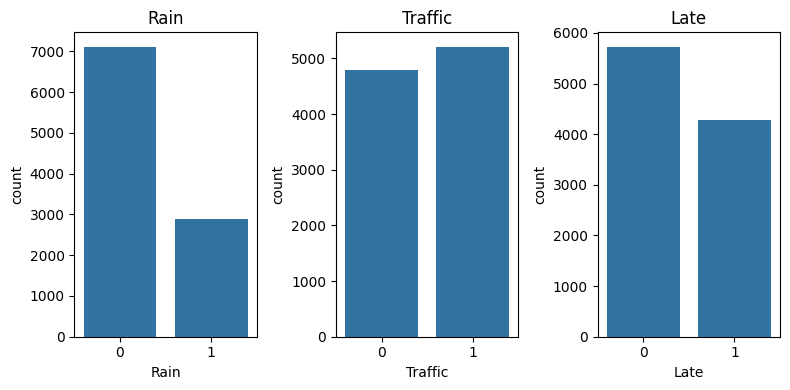

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

node_list = ['Rain', 'Traffic', 'Late']

plt.figure(figsize=(8,4))
for i, node in enumerate(node_list):
    plt.subplot(1,3,i+1)
    sns.countplot(x=samples[node])
    plt.title(node)
plt.tight_layout()
plt.show()

Here, we creates the same three directed edges and draws the network.

The graph shows that Rain has no parent. The parent of Traffic is Rain, and the parents of Late are Rain and Traffic.

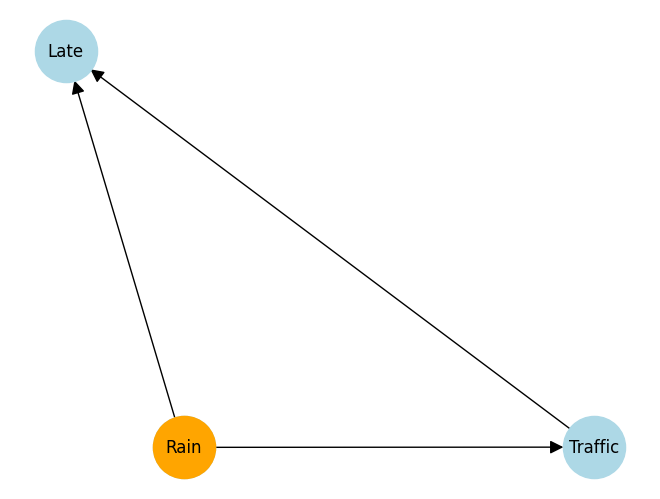

In [ ]:
import networkx as nx

G = nx.DiGraph()
edges = [('Rain','Traffic'), ('Traffic','Late'), ('Rain','Late')]
G.add_edges_from(edges)
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000, arrowsize=20)

nx.draw_networkx_nodes(G, pos, nodelist=['Rain'], node_color='orange', node_size=2000)
plt.show()

# Parameter Count in This Example

For a binary variable, knowing one probability determines the other. For example, if $P(Rain=1)=0.3$, then $P(Rain=0)=1-0.3=0.7$. Therefore, one binary distribution needs only one independent parameter.

## 1. Full Joint Distribution

Rain, Traffic, and Late are all binary variables, so the full joint distribution has:

$$2^3=8$$

probability entries. Since all entries must sum to 1, only $8-1=7$ parameters are independent.

## 2. Bayesian Network

### Rain

Rain has no parents, so it needs 1 independent parameter.

### Traffic

Traffic has one binary parent, Rain. We need one parameter for each possible value of Rain:

- $Rain=0$
- $Rain=1$

Therefore, Traffic needs 2 independent parameters.

### Late

Late has two binary parents, Rain and Traffic. They have four possible configurations:

| Rain | Traffic |
|---:|---:|
| 0 | 0 |
| 0 | 1 |
| 1 | 0 |
| 1 | 1 |

We need one independent parameter for each configuration, so Late needs 4 parameters.

## 3. Total

$$1+2+4=7$$

In this small and densely connected network, the Bayesian Network and the full joint distribution both require 7 independent parameters. Here, the network mainly helps us organize the probability relationships and perform inference.

**A Bayesian Network allows us to efficiently and structurally represent and work with complex joint probability distributions through a DAG and CPDs, while capturing conditional independencies and supporting data generation.**

# When Does a Bayesian Network Save Parameters?

In a full joint distribution, every additional binary variable doubles the number of possible configurations.

For 10 binary variables, the full joint table contains:

$$2^{10}=1024$$

entries, or $1024-1=1023$ independent parameters.

A Bayesian Network uses smaller local probability tables. Each node only needs to consider its own parents.

If every node has at most 2 binary parents, each node needs at most:

$$2^2=4$$

independent parameters. For 10 nodes, this is approximately at most:

$$10\times4=40$$

| Representation | Number of Independent Parameters |
|---|---:|
| Full joint distribution | 1023 |
| Bayesian Network | approximately at most 40 |

A Bayesian Network can therefore save many parameters when the network has many nodes and each node has only a few parents.

---

# Example: naive Bayes for classification

## A Simplified Example with Three Words

We want to classify an email as **spam** or **non-spam** by checking whether three words appear.

| Feature | Meaning |
|---|---|
| $X_1$ | whether "free" appears |
| $X_2$ | whether "win" appears |
| $X_3$ | whether "meeting" appears |

For each feature, 1 means the word appears and 0 means it does not appear. The class variable is:

- $Y=1$: spam
- $Y=0$: non-spam

## Step 1: Learn Probabilities from the Training Data

The training set contains 10 emails: 5 spam and 5 non-spam. Therefore:

$$P(Y=1)=0.5, \qquad P(Y=0)=0.5$$

The word counts are:

| Class | "free" appears | "win" appears | "meeting" appears |
|---|---:|---:|---:|
| Spam: 5 emails | 3 | 3 | 1 |
| Non-spam: 5 emails | 1 | 0 | 4 |

For example, "free" appears in 3 of the 5 spam emails, so:

$$P(X_1=1\mid Y=1)=\frac{3}{5}=0.6$$

For a binary feature, the probability that a word does not appear is 1 minus the probability that it appears. For example:

$$P(X_1=0\mid Y=1)=1-0.6=0.4$$

## Step 2: Represent the New Email

The new email contains "free" and "win," but does not contain "meeting." Therefore:

$$[X_1,X_2,X_3]=[1,1,0]$$

We only need the probabilities that match these observed features:

| Class | Prior | $X_1=1$ | $X_2=1$ | $X_3=0$ |
|---|---:|---:|---:|---:|
| Spam | 0.5 | 0.6 | 0.6 | 0.8 |
| Non-spam | 0.5 | 0.2 | 0 | 0.2 |

Notice that we use $X_3=0$ because the new email does not contain "meeting."

## Step 3: Calculate a Score for Each Class

From Bayes' theorem:

$$P(Y\mid X)=\frac{P(X\mid Y)P(Y)}{P(X)}$$

For the same email, $P(X)$ is the same for every possible class. Therefore, comparing the posterior probabilities only requires comparing their numerators. We define this numerator as the class score:

$$Score(Y)=P(Y)P(X\mid Y)$$

A larger score gives a larger posterior probability, so we can use the scores to choose the predicted class.

Naive Bayes assumes that the word features are conditionally independent after the class is known. We therefore multiply the prior and the three matching conditional probabilities.

### Spam Score

$$\begin{aligned}
Score(Spam)
&=P(Y=1)P(X_1=1\mid Y=1)P(X_2=1\mid Y=1)P(X_3=0\mid Y=1)\\
&=0.5\times0.6\times0.6\times0.8\\
&=0.144
\end{aligned}$$

### Non-Spam Score

$$\begin{aligned}
Score(Non\text{-}spam)
&=P(Y=0)P(X_1=1\mid Y=0)P(X_2=1\mid Y=0)P(X_3=0\mid Y=0)\\
&=0.5\times0.2\times0\times0.2\\
&=0
\end{aligned}$$

The non-spam score is 0 because none of the non-spam training emails contains "win."

## Step 4: Compare the Scores

| Class | Score |
|---|---:|
| Spam | 0.144 |
| Non-spam | 0 |

For classification, we can directly compare the two scores. Since $0.144>0$, the predicted class is **spam**.

## Step 5: Convert the Scores into Posterior Probabilities

The total score is:

$$0.144+0=0.144$$

After normalization:

$$P(Y=1\mid X_1=1,X_2=1,X_3=0)=\frac{0.144}{0.144}=1$$

$$P(Y=0\mid X_1=1,X_2=1,X_3=0)=\frac{0}{0.144}=0$$

**Final prediction: Spam ($Y=1$).**

> The probabilities become exactly 1 and 0 because the training set is very small and one observed frequency is zero.